#### This script uses five classifiers, linear,ann,knn,protonet and random_forest to get a final classifier using the slide aggregations.
#### It also outputs results metrics such as Balance accuracy, AUROC etc into a csv in the output folder.

In [1]:
import os
os.getcwd()

'd:\\Aamir Gulzar\\KSA_project2\\Cancer-detection-classifier\\slide_classification'

## Hugging face login

In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
load_dotenv()
from huggingface_hub import login

login(os.environ["HF_TOKEN"])

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to C:\Users\datainsight\.cache\huggingface\token
Login successful


In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
import os
from os.path import join as j_
from PIL import Image
import pandas as pd
import numpy as np
import time
import random
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import Lambda
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
# loading all packages here to start
# from dataloader import WSIDataset
from eval_patch_features.logistic import eval_linear
from eval_patch_features.ann import eval_ANN
from eval_patch_features.knn import eval_knn
from eval_patch_features.protonet import eval_protonet
from eval_patch_features.r_forest_eval import eval_r_forest
from eval_patch_features.metrics import get_eval_metrics, print_metrics
from utility import calculate_metric_averages, average_confusion_matrices, write_data_in_excel, build_probs_df
from Tissue_Type_Combinations_Exp.TTC_combination_experiment import run_tissue_combination_search
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Blind test all TTC combinations

In [7]:
import os
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import torch
from torch.utils.data import Dataset
from typing import List
import pandas as pd

# --- DYNAMIC CONFIGURATIONS ---
AGGREGATION_METHODS = ["Averaging", "Caption_based_aggregation", "Tissue_Type_Clustering", "TITAN"] # Averaging , Caption_based_aggregation , Tissue_Type_Clustering , TITAN 
MODEL_NAMES = ["H-Optimus-1" , "Conch1_5" , "UNI2" , "Virchow2" , "ConchV1"] # H-Optimus-1 , Conch1_5 , UNI2 , Virchow2 , ConchV1                             
RESULT_FOLDER = "TCGA_Results_Updated"

# Define Base Dimensions for each model
MODEL_BASE_DIMS = {
    "H-Optimus-1": 1536,
    "UNI2": 1536,
    "Conch1_5": 768,
    "Virchow2": 2560,
    "ConchV1": 512
}

# Define Multipliers for each aggregation method
AGG_MULTIPLIERS = {
    "Caption_based_aggregation": 14,
    "Tissue_Type_Clustering": 9,
    "Averaging": 1
}

TASK_PREFIXES = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP"
}

TISSUE_CLASS_NAMES = [
    "adipose",          # 0
    "background",       # 1
    "debris",           # 2
    "lymphocyte",       # 3
    "mucin",            # 4
    "smooth_muscle",    # 5
    "normal_mucosa",    # 6
    "stroma",           # 7
    "tumor",            # 8
]

HIDDEN_DIM = 128
BATCH_SIZE = 4
task_names = ["MSIH"]  # "MSIH", "BRAF", "KRAS", "TP53", "CIMP"

BASE_ROOT = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT = os.path.join(BASE_ROOT, "Cancer-detection-classifier", "slide_classification")

sheet_name = "baseline"

# ===========================================================================
# OUTER LOOP: Iterate over all (aggregation_method, model_name) combinations
# ===========================================================================
for AGGREGATION_METHOD in AGGREGATION_METHODS:
    for MODEL_NAME in MODEL_NAMES:

        # TITAN is only used with Conch1_5, so we skip incompatible combinations
        if AGGREGATION_METHOD == "TITAN" and MODEL_NAME != "Conch1_5":
            continue

        print(f"\n{'='*70}")
        print(f"  Aggregation: {AGGREGATION_METHOD} | Model: {MODEL_NAME}")
        print(f"{'='*70}\n")

        # Calculate VECTOR_DIM automatically
        # TITAN is a special case (768 regardless), so we handle it with a fallback
        if AGGREGATION_METHOD == "TITAN":
            VECTOR_DIM = 768
        else:
            base = MODEL_BASE_DIMS.get(MODEL_NAME, 768)
            mult = AGG_MULTIPLIERS.get(AGGREGATION_METHOD, 1)
            VECTOR_DIM = base * mult

        K_FOLDS_PATH = os.path.join(PROJECT_ROOT, "kfolds_IDARS_fixed.csv")
        DATA_PATH = os.path.join(BASE_ROOT, "dataset", "slide_aggregation", AGGREGATION_METHOD, MODEL_NAME)
        RESULT_ROOT = os.path.join(PROJECT_ROOT, RESULT_FOLDER, AGGREGATION_METHOD, MODEL_NAME)

        for task_name in task_names:
            folder_task_name = TASK_PREFIXES.get(task_name, task_name)

            # Build task-specific paths
            MODEL_SAVE_PATH = os.path.join(RESULT_ROOT, folder_task_name, "models")
            OUTPUT_SAVE_PATH = os.path.join(RESULT_ROOT, folder_task_name, "Output")

            # Create directories
            os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
            os.makedirs(OUTPUT_SAVE_PATH, exist_ok=True)

            # Final File Paths
            EVAL_METRICS_EXCEL = os.path.join(OUTPUT_SAVE_PATH, "cross_valid_avg_eval_metrics.xlsx")
            PROBS_ALL_EXCEL = os.path.join(OUTPUT_SAVE_PATH, "cross_valid_avg_probs_all.xlsx")

            print(f"Processing Task: {task_name} using {MODEL_NAME} via {AGGREGATION_METHOD}")

            class WSIDataset(Dataset):
                def __init__(self, save_dir: str, fold_ids: List[str]):
                    self.data = []
                    self.save_dir = save_dir
                    self.fold_ids = fold_ids
                    self._load_data()

                def _load_data(self):
                    files = os.listdir(self.save_dir)
                    # Change this depending on your classification task
                    if task_name == "MSIH":
                        K_FOLDS_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv"
                    elif task_name == "BRAF":
                        K_FOLDS_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv"
                    elif task_name == "KRAS":
                        K_FOLDS_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv"
                    elif task_name == "TP53":
                        K_FOLDS_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv"
                    else:
                        raise ValueError(f"Unknown task name: {task_name}")

                    folds_df = pd.read_csv(K_FOLDS_PATH)

                    for wsi_file in files:
                        wsi_path = os.path.join(self.save_dir, wsi_file)

                        # Extract WSI ID without extension
                        wsi_id = os.path.splitext(wsi_file)[0]

                        # Skip files not in fold_ids
                        if wsi_id not in self.fold_ids:
                            continue

                        # Only process .pt files
                        if not wsi_path.endswith('.pt'):
                            continue

                        try:
                            # Load WSI features
                            wsi_features = torch.load(wsi_path)

                            if wsi_features.is_cuda:
                                wsi_features = wsi_features.cpu()

                            # Average or flatten features
                            if wsi_features.dim() > 1:
                                final_features = wsi_features.flatten()
                            else:
                                final_features = wsi_features

                            # Determine label based on task_name
                            if task_name == "MSIH":
                                # MSIH classification
                                if wsi_id in folds_df['WSI_Id'].values:
                                    fold_label = folds_df.loc[folds_df['WSI_Id'] == wsi_id, 'label_desc'].values[0]
                                    label = 0 if fold_label == 'nonMSIH' else 1

                            elif task_name == "BRAF":
                                # BRAF classification
                                if wsi_id in folds_df['WSI_Id'].values:
                                    fold_label = folds_df.loc[folds_df['WSI_Id'] == wsi_id, 'BRAF_mutation'].values[0]
                                    label = 0 if fold_label == 'WT' else 1

                            elif task_name == "KRAS":
                                # KRAS classification
                                if wsi_id in folds_df['WSI_Id'].values:
                                    fold_label = folds_df.loc[folds_df['WSI_Id'] == wsi_id, 'KRAS_mutation'].values[0]
                                    label = 0 if fold_label == 'WT' else 1

                            elif task_name == "TP53":
                                # TP53 classification
                                if wsi_id in folds_df['WSI_Id'].values:
                                    fold_label = folds_df.loc[folds_df['WSI_Id'] == wsi_id, 'TP53_mutation'].values[0]
                                    label = 0 if fold_label == 'WT' else 1

                            else:
                                raise ValueError(f"Unknown task name: {task_name}")

                            # Store in dataset
                            self.data.append((final_features, label, wsi_id))

                        except Exception as e:
                            print(f"[ERROR] Loading failed for {wsi_path}: {e}")

                def __len__(self):
                    return len(self.data)

                def __getitem__(self, idx):
                    features, label, wsi_id = self.data[idx]
                    return features, label, wsi_id


            # Pipeline 2
            from itertools import product

            def train_and_evaluate(fold, train_loader, val_loader, test_loader, model_type='linear'):
                def get_feats_labels(loader):
                    feats, labels, ids = [], [], []
                    for features, lbls, wsi_ids in loader:
                        feats.append(features)
                        labels.append(lbls)
                        if isinstance(wsi_ids, (list, tuple)):
                            ids.extend(wsi_ids)
                        else:
                            ids.append(wsi_ids)
                    return torch.cat(feats), torch.cat(labels), ids

                train_feats, train_labels, _ = get_feats_labels(train_loader)
                val_feats, val_labels, _ = get_feats_labels(val_loader)
                test_feats, test_labels, all_test_ids = get_feats_labels(test_loader)

                best_metrics = None
                best_dump = None
                best_params = None

                if model_type == 'lin':
                    param_grid = {
                        'C': [10],
                        'max_iter': [300]
                    }
                    for C, max_iter in product(param_grid['C'], param_grid['max_iter']):
                        eval_metrics, eval_dump = eval_linear(
                            fold=fold,
                            train_feats=train_feats,
                            train_labels=train_labels,
                            valid_feats=val_feats,
                            valid_labels=val_labels,
                            test_feats=test_feats,
                            test_labels=test_labels,
                            max_iter=max_iter,
                            save_path=MODEL_SAVE_PATH,
                            C=C,
                            verbose=False,
                        )
                        if not best_metrics or eval_metrics['lin_macro_f1'] > best_metrics['lin_macro_f1']:
                            best_metrics = eval_metrics
                            best_dump = eval_dump
                            best_params = (C, max_iter)

                elif model_type == 'ann':
                    param_grid = {
                        'hidden_dim1': [128, 256],
                        'hidden_dim2': [64, 128],
                        'max_iter': [500]
                    }
                    for h1, h2, max_iter in product(param_grid['hidden_dim1'], param_grid['hidden_dim2'], param_grid['max_iter']):
                        eval_metrics, eval_dump = eval_ANN(
                            fold=fold,
                            train_feats=train_feats,
                            train_labels=train_labels,
                            valid_feats=val_feats,
                            valid_labels=val_labels,
                            test_feats=test_feats,
                            test_labels=test_labels,
                            input_dim=VECTOR_DIM,
                            hidden_dim=h1,
                            hidden_dim2=h2,
                            max_iter=max_iter,
                            model_save_path=MODEL_SAVE_PATH,
                            verbose=False,
                        )
                        if not best_metrics or eval_metrics['ann_macro_f1'] > best_metrics['ann_macro_f1']:
                            best_metrics = eval_metrics
                            best_dump = eval_dump
                            best_params = (h1, h2, max_iter)

                elif model_type == 'knn':
                    for k in [3]:
                        eval_metrics, eval_dump = eval_knn(
                            fold=fold,
                            train_feats=train_feats,
                            train_labels=train_labels,
                            val_feats=val_feats,
                            val_labels=val_labels,
                            test_feats=test_feats,
                            test_labels=test_labels,
                            n_neighbors=k,
                            normalize_feats=True,
                            model_save_path=MODEL_SAVE_PATH,
                            verbose=False
                        )
                        if not best_metrics or eval_metrics['knn_macro_f1'] > best_metrics['knn_macro_f1']:
                            best_metrics = eval_metrics
                            best_dump = eval_dump
                            best_params = k

                elif model_type == 'proto':
                    eval_metrics, eval_dump = eval_protonet(
                        fold=fold,
                        train_feats=train_feats,
                        train_labels=train_labels,
                        val_feats=val_feats,
                        val_labels=val_labels,
                        test_feats=test_feats,
                        test_labels=test_labels,
                        normalize_feats=True,
                        model_save_path=MODEL_SAVE_PATH,
                    )
                    best_metrics = eval_metrics
                    best_dump = eval_dump
                    best_params = None

                elif model_type == 'rf':
                    param_grid = {
                        'n_estimators': [500],
                        'max_depth': [None],
                        'min_samples_split': [5],
                        'min_samples_leaf': [1],
                        'class_weight': [{0: 1, 1: 10}],
                        'prediction_threshold': [0.3]
                    }
                    for n_est, max_d, min_split, min_leaf, cw, thresh in product(
                        param_grid['n_estimators'],
                        param_grid['max_depth'],
                        param_grid['min_samples_split'],
                        param_grid['min_samples_leaf'],
                        param_grid['class_weight'],
                        param_grid['prediction_threshold']
                    ):
                        eval_metrics, eval_dump = eval_r_forest(
                            fold=fold,
                            train_feats=train_feats,
                            train_labels=train_labels,
                            valid_feats=val_feats,
                            valid_labels=val_labels,
                            test_feats=test_feats,
                            test_labels=test_labels,
                            n_estimators=n_est,
                            max_depth=max_d,
                            min_samples_split=min_split,
                            min_samples_leaf=min_leaf,
                            class_weight=cw,
                            prediction_threshold=thresh,
                            save_path=MODEL_SAVE_PATH,
                            verbose=False,
                        )
                        if not best_metrics or eval_metrics['rf_macro_f1'] > best_metrics['rf_macro_f1']:
                            best_metrics = eval_metrics
                            best_dump = eval_dump
                            best_params = (n_est, max_d, min_split, min_leaf, cw, thresh)

                else:
                    raise ValueError(f"Unsupported model type: {model_type}")

                if best_params:
                    print(f"Fold {fold} | Best Params for {model_type}: {best_params}")
                return best_metrics, best_dump, all_test_ids

            from typing import List
            def run_k_fold_cross_validation(save_dir: str, folds: List[List[str]], model_type: str = 'lin'):
                results_per_fold = []
                num_folds = len(folds)

                for i in range(num_folds):
                    # Define test and validation folds
                    test_ids = folds[i]
                    val_ids = folds[(i + 1) % num_folds]

                    # Use remaining folds as training
                    train_ids = []
                    for j in range(num_folds):
                        if j != i and j != (i + 1) % num_folds:
                            train_ids.extend(folds[j])
                    print(f"Running Fold {i + 1} with model {model_type}...")
                    print(f"  Train IDs count: {len(train_ids)}, Val IDs count: {len(val_ids)}, Test IDs count: {len(test_ids)}")
                    # Create datasets and loaders
                    train_dataset = WSIDataset(save_dir, train_ids)
                    val_dataset = WSIDataset(save_dir, val_ids)
                    test_dataset = WSIDataset(save_dir, test_ids)
                    print(f"  Dataset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
                    if len(train_dataset) == 0 or len(val_dataset) == 0 or len(test_dataset) == 0:
                        print(f"  ERROR: Empty dataset detected!")
                        print(f"  Sample train IDs: {train_ids[:3] if train_ids else 'None'}")
                        print(f"  Files in directory: {os.listdir(save_dir)[:5]}")
                        raise ValueError("Empty dataset - check WSI ID matching with files in directory")
                    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
                    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
                    eval_metrics, eval_dump, all_test_ids = train_and_evaluate(i, train_loader, val_loader, test_loader, model_type=model_type)
                    print_metrics(eval_metrics)
                    result = {
                        **eval_metrics,
                        **eval_dump,
                        "wsi_ids": all_test_ids,
                        "fold": i + 1
                    }
                    results_per_fold.append(result)
                return results_per_fold

            # Load CSV containing fold and wsi_id
            folds_df = pd.read_csv(K_FOLDS_PATH)

            # Group wsi_ids by fold
            num_folds = folds_df['fold'].nunique()
            folds = []
            for fold_num in sorted(folds_df['fold'].unique()):
                wsi_ids = folds_df[folds_df['fold'] == fold_num]['WSI_Id'].tolist()
                folds.append(wsi_ids)

            # Run k-fold cross-validation with different models
            model_types = ['lin', 'ann', 'knn', 'proto', 'rf']
            metric_indices = {
                'acc': 0,
                'bacc': 1,
                'macro_f1': 2,
                'weighted_f1': 3,
                'auroc': 4
            }

            eval_metrics__for_excel = []
            probs_all_for_excel = None
            for model in model_types:
                predictions_list = []
                print(f"\n\n ********* Training with model: {model}********* \n\n")
                k_folds_results = run_k_fold_cross_validation(DATA_PATH, folds, model_type=model)
                model_df = build_probs_df(k_folds_results, model_name=model)
                # === Merge predictions across models ===
                if probs_all_for_excel is None:
                    probs_all_for_excel = model_df
                else:
                    probs_all_for_excel = pd.merge(probs_all_for_excel, model_df, on=["Fold", "WSI_ID", "Target"], how="outer")

                # === Average metrics (only pass metric parts of result dicts)
                average_results = calculate_metric_averages(
                    [{k: v for k, v in result.items() if k in [f"{model}_{m}" for m in metric_indices.keys()]}
                    for result in k_folds_results],
                    metric_indices,
                    model_prefix=model
                )
                # === Confusion matrices
                confusion_matrices = [np.array(result[f"{model}_conf_matrix"]) for result in k_folds_results if f"{model}_conf_matrix" in result]

                avg_conf_matrix = average_confusion_matrices(confusion_matrices)
                print("\n\n Average results for all folds:")
                for metric, value in average_results.items():
                    print(f"{metric}: {value:.4f}")
                # Append per metric rows for each fold + average
                for metric in metric_indices.keys():
                    row = [f"{model}_{metric}"]
                    for result in k_folds_results:
                        row.append(result.get(f"{model}_{metric}", 'N/A'))
                    row.append(average_results.get(f"{model}_{metric}", 'N/A'))
                    eval_metrics__for_excel.append(row)

                # Append confusion matrix as string (per fold)
                row = [f"{model}_conf_matrix"]
                for result in k_folds_results:
                    row.append(str(result.get(f"{model}_conf_matrix", "N/A")))
                row.append(str(avg_conf_matrix))
                eval_metrics__for_excel.append(row)

            eval_metrics_df = pd.DataFrame(eval_metrics__for_excel,
                                    columns=["Metric", "Fold1", "Fold2", "Fold3", "Fold4", "AvgFolds"])
            write_data_in_excel(EVAL_METRICS_EXCEL, eval_metrics_df, sheet_name=sheet_name)
            write_data_in_excel(PROBS_ALL_EXCEL, probs_all_for_excel, sheet_name=sheet_name)
            # === Tissue Combination Search (only for Tissue_Type_Clustering) ===
            if AGGREGATION_METHOD == "Tissue_Type_Clustering":
                run_tissue_combination_search(
                    task_name          = task_name,
                    data_path          = DATA_PATH,
                    k_folds_path       = K_FOLDS_PATH,
                    folds              = folds,
                    output_save_path   = OUTPUT_SAVE_PATH,
                    num_tissue_classes = 9,
                    feature_dim        = MODEL_BASE_DIMS[MODEL_NAME],
                    k_values           = [3,5], # 1,2,3,4,5 etc
                    model_types        = ["lin", "ann", "knn", "proto", "rf"], # "lin", "ann", "knn", "proto", "rf"
                    rank_by            = "bacc",
                    tissue_class_names = TISSUE_CLASS_NAMES,
                )


  Aggregation: Averaging | Model: H-Optimus-1

Processing Task: MSIH using H-Optimus-1 via Averaging


 ********* Training with model: lin********* 


Running Fold 1 with model lin...
  Train IDs count: 215, Val IDs count: 98, Test IDs count: 103
  Dataset sizes - Train: 213, Val: 97, Test: 103
Fold 0 | Best Params for lin: (10, 300)
lin_acc: 0.8932
lin_bacc: 0.7163
lin_macro_f1: 0.7496
lin_weighted_f1: 0.8840
lin_auroc: 0.9053
lin_conf_matrix: [[85  3]
 [ 8  7]]
Running Fold 2 with model lin...
  Train IDs count: 206, Val IDs count: 112, Test IDs count: 98
  Dataset sizes - Train: 204, Val: 112, Test: 97
Fold 1 | Best Params for lin: (10, 300)
lin_acc: 0.9485
lin_bacc: 0.8402
lin_macro_f1: 0.8767
lin_weighted_f1: 0.9455
lin_auroc: 0.9304
lin_conf_matrix: [[83  1]
 [ 4  9]]
Running Fold 3 with model lin...
  Train IDs count: 201, Val IDs count: 103, Test IDs count: 112
  Dataset sizes - Train: 200, Val: 101, Test: 112
Fold 2 | Best Params for lin: (10, 300)
lin_acc: 0.9107
lin_bacc: 0

## Method 2 : Check individual results then match

In [ ]:
"""
tissue_combination_search.py
─────────────────────────────────────────────────────────────────────────────
Runs two phases of experiments for Tissue_Type_Clustering features only:

  Phase 1 — Individual class evaluation
      Tests each of the 9 tissue classes in isolation (1×N vector).
      Results are saved to: tissue_individual_class_results.xlsx
      Classes are then ranked by bacc and grouped into tiers:
          Strong  (bacc ≥ STRONG_THRESHOLD)
          Neutral (bacc ≥ NEUTRAL_THRESHOLD)
          Weak    (bacc <  NEUTRAL_THRESHOLD)

  Phase 2 — Smart combination search
      Combinations are filtered by tier rules before testing:
          • MAX_WEAK_PERCENT    — skip if too many Weak classes
          • MAX_NEUTRAL_PERCENT — skip if too many Neutral classes
          • MIN_STRONG_COUNT    — skip if too few Strong classes
      Results are saved to: tissue_combo_summary_k{k}.xlsx (ranked by bacc)

  Model saving
      One best model is kept per (foundation model, k value).
      Saved to: …/models/best_{k}labels_TTC/
      All intermediate checkpoints are deleted immediately after each combo.
"""

import os
import gc
import shutil
import itertools
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from itertools import product as iproduct

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAMES = ["Conch1_5", "UNI2", "Virchow2", "ConchV1" ]  # "H-Optimus-1", "Conch1_5", "UNI2", "Virchow2", "ConchV1"

MODEL_BASE_DIMS = {
    "H-Optimus-1": 1536,
    "UNI2":        1536,
    "Conch1_5":     768,
    "Virchow2":    2560,
    "ConchV1":      512,
}

TASK_PREFIXES = {
    "MSIH": "1-MSIH",
    "BRAF": "2-BRAF",
    "KRAS": "3-KRAS",
    "TP53": "4-TP53",
    "CIMP": "5-CIMP",
}

# Map task_name → (csv_path, label_column, negative_value)
TASK_FOLD_CONFIG = {
    "MSIH": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\kfolds_IDARS_fixed.csv",
             "label_desc",    "nonMSIH"),
    "BRAF": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_BRAF.csv",
             "BRAF_mutation", "WT"),
    "KRAS": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_KRAS.csv",
             "KRAS_mutation", "WT"),
    "TP53": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_TP53.csv",
             "TP53_mutation", "WT"),
    "CIMP": (r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Slide_Classification\kfold_CIMP.csv",
             "CIMP",          "neg"),
}

TISSUE_CLASS_NAMES = [
    "adipose",       # 0
    "background",    # 1
    "debris",        # 2
    "lymphocyte",    # 3
    "mucin",         # 4
    "smooth_muscle", # 5
    "normal_mucosa", # 6
    "stroma",        # 7
    "tumor",         # 8
]
NUM_TISSUE_CLASSES = 9

BATCH_SIZE  = 4
task_names  = ["MSIH"]                           # extend as needed
model_types = ["lin", "ann", "knn", "proto", "rf"]
k_values    = [3]                                # combination sizes for Phase 2
rank_by     = "bacc"                             # metric used for ranking/tiers

# Tier thresholds (applied to avg per-class bacc from Phase 1)
STRONG_THRESHOLD  = 0.65   # bacc ≥ this → Strong
NEUTRAL_THRESHOLD = 0.58   # bacc ≥ this → Neutral, else Weak

# Phase 2 combination filters
MAX_WEAK_PERCENT    = 0.45  # skip combo if >45% of its classes are Weak
MAX_NEUTRAL_PERCENT = 0.70  # skip combo if >70% of its classes are Neutral
MIN_STRONG_COUNT    = 1     # skip combo if fewer than this many Strong classes

RESULT_FOLDER      = "TCGA_Results_Updated"
BASE_ROOT          = r"D:\Aamir Gulzar\KSA_project2"
PROJECT_ROOT       = os.path.join(BASE_ROOT, "Cancer-detection-classifier", "slide_classification")
AGGREGATION_METHOD = "Tissue_Type_Clustering"
sheet_name         = "tissue_search"


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────

class TissueCombinationDataset(Dataset):
    """
    Loads flattened (num_classes × feature_dim) .pt tensors and exposes
    only the rows listed in `row_indices`, re-flattened to (k × feature_dim).
    """

    def __init__(
        self,
        save_dir:     str,
        fold_ids:     List[str],
        row_indices:  List[int],
        num_classes:  int,
        feature_dim:  int,
        label_col:    str,
        neg_value:    str,
        k_folds_path: str,
    ):
        self.save_dir    = save_dir
        self.fold_ids    = set(fold_ids)
        self.row_indices = row_indices
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.label_col   = label_col
        self.neg_value   = neg_value

        folds_df      = pd.read_csv(k_folds_path)
        self.folds_df = folds_df.set_index("WSI_Id")

        self.data: List[Tuple[torch.Tensor, int, str]] = []
        self._load()

    def _load(self):
        expected_len = self.num_classes * self.feature_dim

        for fname in os.listdir(self.save_dir):
            if not fname.endswith(".pt"):
                continue
            wsi_id = os.path.splitext(fname)[0]
            if wsi_id not in self.fold_ids:
                continue
            if wsi_id not in self.folds_df.index:
                continue

            try:
                feats = torch.load(
                    os.path.join(self.save_dir, fname), map_location="cpu"
                )
                flat = feats.cpu().flatten()

                if flat.numel() != expected_len:
                    print(f"[WARN] {fname}: expected {expected_len} elements, "
                          f"got {flat.numel()}. Skipping.")
                    continue

                matrix   = flat.view(self.num_classes, self.feature_dim)
                selected = matrix[self.row_indices].flatten()

                raw   = self.folds_df.at[wsi_id, self.label_col]
                label = 0 if raw == self.neg_value else 1

                self.data.append((selected, label, wsi_id))

            except Exception as exc:
                print(f"[ERROR] {fname}: {exc}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, label, wsi_id = self.data[idx]
        return feats, label, wsi_id


# ─────────────────────────────────────────────────────────────────────────────
# MODEL SAVING HELPERS
# ─────────────────────────────────────────────────────────────────────────────

class BestModelTracker:
    """
    Tracks the single best model checkpoint for one (foundation model, k) pair.
    Deletes any checkpoint that is not the current best immediately.
    Call .cleanup(keep_dir) at the end to move the winner to its final location.
    """

    def __init__(self, label: str):
        self.label      = label
        self.best_score = -1.0
        self.best_path: Optional[str] = None

    def update(self, score: float, candidate_path: Optional[str]) -> bool:
        """
        If `score` beats the current best, delete the old checkpoint and
        register the new one. Otherwise delete the candidate immediately.
        Returns True if a new best was found.
        """
        if score <= self.best_score:
            if candidate_path and os.path.exists(candidate_path):
                try:
                    os.remove(candidate_path)
                except OSError:
                    pass
            return False

        # New best — remove old checkpoint
        if self.best_path and os.path.exists(self.best_path):
            try:
                os.remove(self.best_path)
            except OSError:
                pass

        self.best_score = score
        self.best_path  = candidate_path
        return True

    def cleanup(self, keep_dir: str):
        """
        Copy the best checkpoint to `keep_dir` with a descriptive name,
        then delete the temporary copy.
        """
        if self.best_path and os.path.exists(self.best_path):
            os.makedirs(keep_dir, exist_ok=True)
            dest = os.path.join(
                keep_dir,
                f"best_{self.label}_{rank_by}{self.best_score:.4f}.pt",
            )
            shutil.copy2(self.best_path, dest)
            try:
                os.remove(self.best_path)
            except OSError:
                pass
            print(f"  ✓ Best model saved → {dest}")
        else:
            print(f"  [WARN] No best model found for {self.label} — nothing saved.")


def _temp_model_dir(output_save_path: str, label: str) -> str:
    """Scratch directory for a single combo's intermediate checkpoints."""
    d = os.path.join(
        output_save_path, "_tmp_models", label.replace("+", "_")
    )
    os.makedirs(d, exist_ok=True)
    return d


def _cleanup_temp_dir(output_save_path: str):
    tmp = os.path.join(output_save_path, "_tmp_models")
    if os.path.isdir(tmp):
        shutil.rmtree(tmp, ignore_errors=True)


# ─────────────────────────────────────────────────────────────────────────────
# K-FOLD RUNNER  (single combo × single model type)
# ─────────────────────────────────────────────────────────────────────────────

def _run_one_combo_kfold(
    task_name:       str,
    data_path:       str,
    k_folds_path:    str,
    folds:           List[List[str]],
    row_indices:     List[int],
    num_classes:     int,
    feature_dim:     int,
    model_type:      str,
    model_save_path: str,
    label_col:       str,
    neg_value:       str,
    tracker:         BestModelTracker,
) -> List[Dict[str, Any]]:
    """
    Runs k-fold CV for one (combo, model_type) pair.
    Calls eval_* functions that must be in scope (imported from your utils).
    Updates `tracker` after every fold.
    """
    vector_dim       = len(row_indices) * feature_dim
    metric_key       = f"{model_type}_macro_f1"
    results_per_fold = []
    num_folds        = len(folds)

    for i in range(num_folds):
        test_ids  = folds[i]
        val_ids   = folds[(i + 1) % num_folds]
        train_ids = [
            wsi_id
            for j, fold in enumerate(folds)
            if j != i and j != (i + 1) % num_folds
            for wsi_id in fold
        ]

        def make_loader(ids, shuffle):
            ds = TissueCombinationDataset(
                save_dir     = data_path,
                fold_ids     = ids,
                row_indices  = row_indices,
                num_classes  = num_classes,
                feature_dim  = feature_dim,
                label_col    = label_col,
                neg_value    = neg_value,
                k_folds_path = k_folds_path,
            )
            if len(ds) == 0:
                raise ValueError(
                    f"Empty dataset for fold {i+1} — "
                    f"check WSI IDs vs files in {data_path}"
                )
            return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

        train_loader = make_loader(train_ids, shuffle=True)
        val_loader   = make_loader(val_ids,   shuffle=False)
        test_loader  = make_loader(test_ids,  shuffle=False)

        def collect(loader):
            feats, labels, ids = [], [], []
            for f, l, w in loader:
                feats.append(f)
                labels.append(l)
                ids.extend(w if isinstance(w, (list, tuple)) else [w])
            return torch.cat(feats), torch.cat(labels), ids

        tr_f, tr_l, _            = collect(train_loader)
        va_f, va_l, _            = collect(val_loader)
        te_f, te_l, test_ids_out = collect(test_loader)

        best_metrics, best_dump, best_params = None, None, None
        last_saved_path = None

        if model_type == "lin":
            for C, max_iter in iproduct([10], [300]):
                m, d = eval_linear(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    max_iter=max_iter, save_path=model_save_path,
                    C=C, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"lin_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (C, max_iter)

        elif model_type == "ann":
            for h1, h2, max_iter in iproduct([128, 256], [64, 128], [500]):
                m, d = eval_ANN(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    input_dim=vector_dim, hidden_dim=h1, hidden_dim2=h2,
                    max_iter=max_iter, model_save_path=model_save_path,
                    verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"ann_fold{i}.pt")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (h1, h2, max_iter)

        elif model_type == "knn":
            for k_n in [3]:
                m, d = eval_knn(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    val_feats=va_f,   val_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_neighbors=k_n, normalize_feats=True,
                    model_save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"knn_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, k_n

        elif model_type == "proto":
            best_metrics, best_dump = eval_protonet(
                fold=i, train_feats=tr_f, train_labels=tr_l,
                val_feats=va_f, val_labels=va_l,
                test_feats=te_f, test_labels=te_l,
                normalize_feats=True, model_save_path=model_save_path,
            )
            last_saved_path = os.path.join(model_save_path, f"proto_fold{i}.pt")
            best_params = None

        elif model_type == "rf":
            for n_est, max_d, min_split, min_leaf, cw, thresh in iproduct(
                [500], [None], [5], [1], [{0: 1, 1: 10}], [0.3]
            ):
                m, d = eval_r_forest(
                    fold=i, train_feats=tr_f, train_labels=tr_l,
                    valid_feats=va_f, valid_labels=va_l,
                    test_feats=te_f,  test_labels=te_l,
                    n_estimators=n_est, max_depth=max_d,
                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                    class_weight=cw, prediction_threshold=thresh,
                    save_path=model_save_path, verbose=False,
                )
                last_saved_path = os.path.join(model_save_path, f"rf_fold{i}.pkl")
                if best_metrics is None or m[metric_key] > best_metrics[metric_key]:
                    best_metrics, best_dump, best_params = m, d, (
                        n_est, max_d, min_split, min_leaf, cw, thresh)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

        # Update tracker — keeps only the single best checkpoint seen so far
        fold_score = best_metrics.get(f"{model_type}_{rank_by}", 0.0)
        tracker.update(fold_score, last_saved_path)

        if best_params:
            print(f"  Fold {i+1} | {model_type} best params: {best_params} | "
                  f"{rank_by}={fold_score:.4f}")

        results_per_fold.append({
            **best_metrics,
            **best_dump,
            "wsi_ids": test_ids_out,
            "fold":    i + 1,
        })

    return results_per_fold


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — individual class evaluation
# ─────────────────────────────────────────────────────────────────────────────

def run_phase1_individual_classes(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
) -> pd.DataFrame:
    """
    Evaluates each tissue class in isolation across all model types.
    Returns a DataFrame (one row per class) with avg metrics and tier labels,
    sorted by best_bacc descending.
    Phase 1 models are not saved — only the tier table matters.
    """
    print(f"\n{'─'*60}")
    print(f"  PHASE 1 — Individual class evaluation")
    print(f"  Model: {model_name} | Task: {task_name}")
    print(f"{'─'*60}")

    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}
    rows = []

    for class_idx, class_name in enumerate(TISSUE_CLASS_NAMES):
        print(f"\n  Class {class_idx}: {class_name}")
        row: Dict[str, Any] = {"class_idx": class_idx, "class_name": class_name}

        model_save_path = _temp_model_dir(output_save_path, f"individual_{class_name}")
        # Local tracker per class — Phase 1 models are discarded after tier assignment
        tracker = BestModelTracker(f"{model_name}_phase1_{class_name}")

        for model_type in model_types:
            try:
                fold_results = _run_one_combo_kfold(
                    task_name       = task_name,
                    data_path       = data_path,
                    k_folds_path    = k_folds_path,
                    folds           = folds,
                    row_indices     = [class_idx],
                    num_classes     = NUM_TISSUE_CLASSES,
                    feature_dim     = feature_dim,
                    model_type      = model_type,
                    model_save_path = model_save_path,
                    label_col       = label_col,
                    neg_value       = neg_value,
                    tracker         = tracker,
                )

                avg = calculate_metric_averages(
                    [{k: v for k, v in r.items()
                      if k in [f"{model_type}_{m}" for m in metric_indices]}
                     for r in fold_results],
                    metric_indices,
                    model_prefix=model_type,
                )
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = avg.get(f"{model_type}_{m}", float("nan"))

            except Exception as exc:
                print(f"    [ERROR] {model_type}: {exc}")
                for m in metric_indices:
                    row[f"{model_type}_{m}"] = float("nan")

        # Average bacc across all model types → used for tier assignment
        bacc_vals = [row.get(f"{mt}_bacc", float("nan")) for mt in model_types]
        bacc_vals = [v for v in bacc_vals if not np.isnan(v)]
        row["best_bacc"] = (
            sum(bacc_vals) / len(bacc_vals) if bacc_vals else float("nan")
        )

        b = row["best_bacc"]
        row["tier"] = (
            "Strong"  if b >= STRONG_THRESHOLD  else
            "Neutral" if b >= NEUTRAL_THRESHOLD else
            "Weak"
        )
        print(f"    best_bacc={b:.4f}  tier={row['tier']}")
        rows.append(row)

    # Phase 1 models are not useful beyond tier assignment — delete them all
    _cleanup_temp_dir(output_save_path)

    df = pd.DataFrame(rows).sort_values("best_bacc", ascending=False)
    out_path = os.path.join(output_save_path, "tissue_individual_class_results.xlsx")
    write_data_in_excel(out_path, df, sheet_name="individual_classes")
    print(f"\n  ✓ Phase 1 results → {out_path}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# TIER-BASED COMBINATION GENERATOR
# ─────────────────────────────────────────────────────────────────────────────

def _smart_combinations(
    class_df: pd.DataFrame, k: int
) -> List[Tuple[int, ...]]:
    """
    Returns all C(9,k) combinations that pass all three tier filters.
    Prints a breakdown of how many combos were removed and why.
    """
    strong  = set(class_df[class_df["tier"] == "Strong" ]["class_idx"].tolist())
    neutral = set(class_df[class_df["tier"] == "Neutral"]["class_idx"].tolist())
    weak    = set(class_df[class_df["tier"] == "Weak"   ]["class_idx"].tolist())

    all_indices = class_df["class_idx"].tolist()
    all_combos  = list(itertools.combinations(all_indices, k))

    filtered          = []
    n_removed_weak    = 0
    n_removed_neutral = 0
    n_removed_strong  = 0

    for combo in all_combos:
        n_weak    = sum(1 for i in combo if i in weak)
        n_neutral = sum(1 for i in combo if i in neutral)
        n_strong  = sum(1 for i in combo if i in strong)

        if n_weak / k > MAX_WEAK_PERCENT:
            n_removed_weak += 1
            continue
        if n_neutral / k > MAX_NEUTRAL_PERCENT:
            n_removed_neutral += 1
            continue
        if n_strong < MIN_STRONG_COUNT:
            n_removed_strong += 1
            continue

        filtered.append(combo)

    print(f"  k={k}: {len(all_combos)} total → {len(filtered)} kept  "
          f"(removed {n_removed_weak} excess-weak, "
          f"{n_removed_neutral} excess-neutral, "
          f"{n_removed_strong} insufficient-strong  |  "
          f"thresholds: max_weak={MAX_WEAK_PERCENT:.0%}, "
          f"max_neutral={MAX_NEUTRAL_PERCENT:.0%}, "
          f"min_strong={MIN_STRONG_COUNT})")
    return filtered


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — combination search
# ─────────────────────────────────────────────────────────────────────────────

def run_phase2_combination_search(
    task_name:        str,
    data_path:        str,
    k_folds_path:     str,
    folds:            List[List[str]],
    feature_dim:      int,
    model_name:       str,
    output_save_path: str,
    label_col:        str,
    neg_value:        str,
    class_df:         pd.DataFrame,
    models_root_dir:  str,
):
    """
    Tests all tier-filtered combinations for each k in k_values.

    One BestModelTracker is created per (foundation model, k).
    At the end of each k, the single best model is saved to:
        models_root_dir/best_{k}labels_TTC/
    """
    metric_indices = {"acc": 0, "bacc": 1, "macro_f1": 2,
                      "weighted_f1": 3, "auroc": 4}

    for k in k_values:
        # One tracker per (foundation model, k) — this is the only model kept
        k_tracker  = BestModelTracker(f"{model_name}_k{k}")
        k_best_dir = os.path.join(models_root_dir, f"best_{k}labels_TTC")
        os.makedirs(k_best_dir, exist_ok=True)

        combos = _smart_combinations(class_df, k)
        print(f"\n{'─'*60}")
        print(f"  PHASE 2 — k={k} | {len(combos)} combos | Model: {model_name}")
        print(f"{'─'*60}")

        summary_rows      = []
        best_combo_score  = -1.0
        best_combo_label  = ""
        best_combo_probs: Optional[pd.DataFrame] = None

        for combo_idx, row_indices in enumerate(combos):
            combo_label = "+".join(TISSUE_CLASS_NAMES[i] for i in row_indices)
            print(f"\n  [{combo_idx+1}/{len(combos)}] {combo_label}")

            model_save_path = _temp_model_dir(output_save_path, combo_label)
            combo_probs_df: Optional[pd.DataFrame] = None  # reset per combo

            for model_type in model_types:
                try:
                    fold_results = _run_one_combo_kfold(
                        task_name       = task_name,
                        data_path       = data_path,
                        k_folds_path    = k_folds_path,
                        folds           = folds,
                        row_indices     = list(row_indices),
                        num_classes     = NUM_TISSUE_CLASSES,
                        feature_dim     = feature_dim,
                        model_type      = model_type,
                        model_save_path = model_save_path,
                        label_col       = label_col,
                        neg_value       = neg_value,
                        tracker         = k_tracker,
                    )

                    # Build per-combo probs (one fresh merge per combo)
                    model_df = build_probs_df(fold_results, model_name=model_type)
                    combo_probs_df = (
                        model_df if combo_probs_df is None
                        else pd.merge(combo_probs_df, model_df,
                                      on=["Fold", "WSI_ID", "Target"], how="outer")
                    )

                    avg = calculate_metric_averages(
                        [{key: v for key, v in r.items()
                          if key in [f"{model_type}_{m}" for m in metric_indices]}
                         for r in fold_results],
                        metric_indices,
                        model_prefix=model_type,
                    )

                    combo_score = avg.get(f"{model_type}_{rank_by}", -1.0)
                    summary_rows.append({
                        "combo":      combo_label,
                        "rows":       str(list(row_indices)),
                        "k":          k,
                        "model_type": model_type,
                        **{m: avg.get(f"{model_type}_{m}", float("nan"))
                           for m in metric_indices},
                    })

                    if combo_score > best_combo_score:
                        best_combo_score = combo_score
                        best_combo_label = combo_label
                        best_combo_probs = (
                            combo_probs_df.copy()
                            if combo_probs_df is not None else None
                        )

                except Exception as exc:
                    print(f"    [ERROR] {model_type}: {exc}")

            # Delete this combo's temp checkpoints immediately —
            # k_tracker already holds the path of the global best so far
            if os.path.isdir(model_save_path):
                shutil.rmtree(model_save_path, ignore_errors=True)
            gc.collect()

        # ── Save ranked summary for this k ────────────────────────────────
        summary_df = (
            pd.DataFrame(summary_rows)
            .sort_values(rank_by, ascending=False)
        )
        summary_path = os.path.join(output_save_path, f"tissue_combo_summary_k{k}.xlsx")
        write_data_in_excel(summary_path, summary_df, sheet_name=f"k{k}")
        print(f"\n  ✓ Summary k={k} → {summary_path}")
        print(f"  Best combo ({rank_by}={best_combo_score:.4f}): {best_combo_label}")

        # ── Save probs for the best combo only ────────────────────────────
        if best_combo_probs is not None:
            probs_path = os.path.join(
                output_save_path, f"tissue_combo_probs_k{k}_best.xlsx"
            )
            write_data_in_excel(probs_path, best_combo_probs,
                                sheet_name=f"k{k}_best_probs")
            print(f"  Best combo probs → {probs_path}")

        # ── Move the best model for this k to its permanent location ──────
        # Final path: …/models/best_{k}labels_TTC/best_{MODEL}_k{k}_bacc0.XXXX.pt
        k_tracker.cleanup(keep_dir=k_best_dir)

    # Remove any leftover temp dirs
    _cleanup_temp_dir(output_save_path)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

for MODEL_NAME in MODEL_NAMES:
    feature_dim = MODEL_BASE_DIMS[MODEL_NAME]

    DATA_PATH   = os.path.join(
        BASE_ROOT, "dataset", "slide_aggregation", AGGREGATION_METHOD, MODEL_NAME
    )
    RESULT_ROOT = os.path.join(
        PROJECT_ROOT, RESULT_FOLDER, AGGREGATION_METHOD, MODEL_NAME
    )

    for task_name in task_names:
        folder_task_name = TASK_PREFIXES.get(task_name, task_name)
        OUTPUT_SAVE_PATH = os.path.join(RESULT_ROOT, folder_task_name, "Output")
        MODELS_ROOT_DIR  = os.path.join(RESULT_ROOT, folder_task_name, "models")

        os.makedirs(OUTPUT_SAVE_PATH, exist_ok=True)
        os.makedirs(MODELS_ROOT_DIR,  exist_ok=True)

        k_folds_path, label_col, neg_value = TASK_FOLD_CONFIG[task_name]

        folds_df = pd.read_csv(k_folds_path)
        folds: List[List[str]] = [
            folds_df[folds_df["fold"] == fn]["WSI_Id"].tolist()
            for fn in sorted(folds_df["fold"].unique())
        ]

        print(f"\n{'='*70}")
        print(f"  Model: {MODEL_NAME} | Task: {task_name}")
        print(f"{'='*70}")

        # ── Phase 1: evaluate each tissue class individually ──────────────
        class_df = run_phase1_individual_classes(
            task_name        = task_name,
            data_path        = DATA_PATH,
            k_folds_path     = k_folds_path,
            folds            = folds,
            feature_dim      = feature_dim,
            model_name       = MODEL_NAME,
            output_save_path = OUTPUT_SAVE_PATH,
            label_col        = label_col,
            neg_value        = neg_value,
        )

        # ── Phase 2: smart combination search, one best model saved per k ─
        run_phase2_combination_search(
            task_name        = task_name,
            data_path        = DATA_PATH,
            k_folds_path     = k_folds_path,
            folds            = folds,
            feature_dim      = feature_dim,
            model_name       = MODEL_NAME,
            output_save_path = OUTPUT_SAVE_PATH,
            label_col        = label_col,
            neg_value        = neg_value,
            class_df         = class_df,
            models_root_dir  = MODELS_ROOT_DIR,
        )

        print(f"\n  ✓ Done: {MODEL_NAME} / {task_name}")


  Model: Conch1_5 | Task: MSIH

────────────────────────────────────────────────────────────
  PHASE 1 — Individual class evaluation
  Model: Conch1_5 | Task: MSIH
────────────────────────────────────────────────────────────

  Class 0: adipose
  Fold 1 | lin best params: (10, 300) | bacc=0.6432
  Fold 2 | lin best params: (10, 300) | bacc=0.5147
  Fold 3 | lin best params: (10, 300) | bacc=0.4957
  Fold 4 | lin best params: (10, 300) | bacc=0.4911
  Fold 1 | ann best params: (128, 128, 500) | bacc=0.5985
  Fold 2 | ann best params: (256, 64, 500) | bacc=0.4931
  Fold 3 | ann best params: (256, 128, 500) | bacc=0.5033
  Fold 4 | ann best params: (256, 64, 500) | bacc=0.5838
  Fold 1 | knn best params: 3 | bacc=0.5000
  Fold 2 | knn best params: 3 | bacc=0.4643
  Fold 3 | knn best params: 3 | bacc=0.5196
  Fold 4 | knn best params: 3 | bacc=0.5913
  Fold 1 | rf best params: (500, None, 5, 1, {0: 1, 1: 10}, 0.3) | bacc=0.5830
  Fold 2 | rf best params: (500, None, 5, 1, {0: 1, 1: 10}, 0

## Generate charts for best combos

[OK] H-Optimus-1 k=3: 84 'ann' rows
[OK] Conch1_5 k=3: 84 'ann' rows
[OK] UNI2 k=3: 84 'ann' rows
[OK] Virchow2 k=3: 84 'ann' rows
[OK] ConchV1 k=3: 84 'ann' rows

Top 5 combos for k=3:
                         combo     mean  H-Optimus-1  Conch1_5     UNI2  Virchow2  ConchV1
            mucin+stroma+tumor 0.777181     0.837284  0.744426 0.769824  0.807123 0.727246
        background+mucin+tumor 0.761387     0.834987  0.699753 0.737818  0.801148 0.733231
background+smooth_muscle+tumor 0.748823     0.807753  0.693386 0.724773  0.765253 0.752948
        lymphocyte+mucin+tumor 0.748310     0.743708  0.743683 0.817231  0.721194 0.715737
           adipose+mucin+tumor 0.745266     0.835769  0.695191 0.727276  0.750082 0.718015
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\top5_combos_k3.png


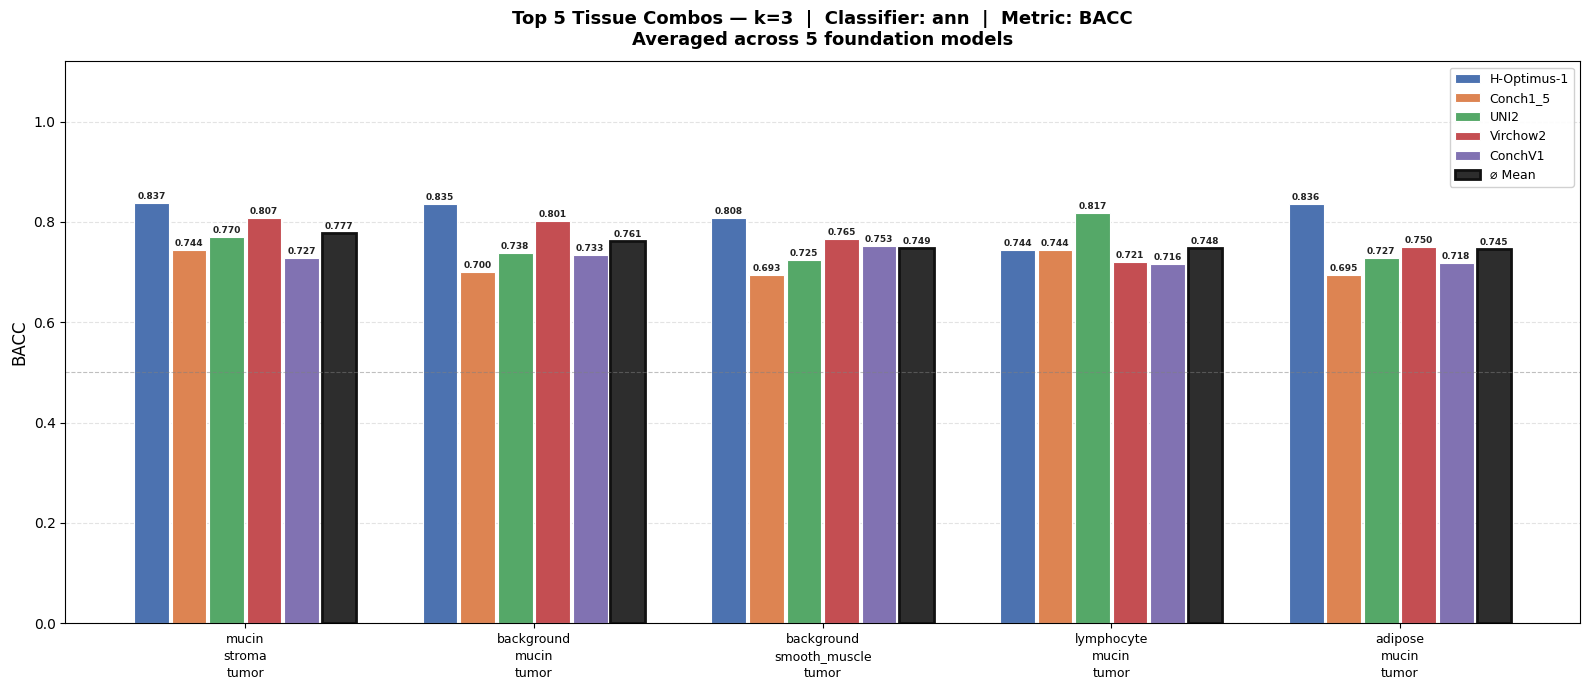

[OK] H-Optimus-1 k=5: 126 'ann' rows
[OK] Conch1_5 k=5: 126 'ann' rows
[OK] UNI2 k=5: 126 'ann' rows
[OK] Virchow2 k=5: 126 'ann' rows
[OK] ConchV1 k=5: 126 'ann' rows

Top 5 combos for k=5:
                                      combo     mean  H-Optimus-1  Conch1_5     UNI2  Virchow2  ConchV1
background+mucin+smooth_muscle+stroma+tumor 0.769908     0.837117  0.746024 0.758684  0.779274 0.728439
background+mucin+normal_mucosa+stroma+tumor 0.761512     0.799092  0.706812 0.807626  0.763720 0.730312
      adipose+lymphocyte+mucin+stroma+tumor 0.761281     0.809952  0.735646 0.811001  0.750515 0.699292
background+debris+mucin+smooth_muscle+tumor 0.756365     0.815977  0.725864 0.755905  0.741019 0.743063
    debris+mucin+smooth_muscle+stroma+tumor 0.755385     0.824073  0.711900 0.752925  0.755974 0.732054
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\top5_combos_k5.png


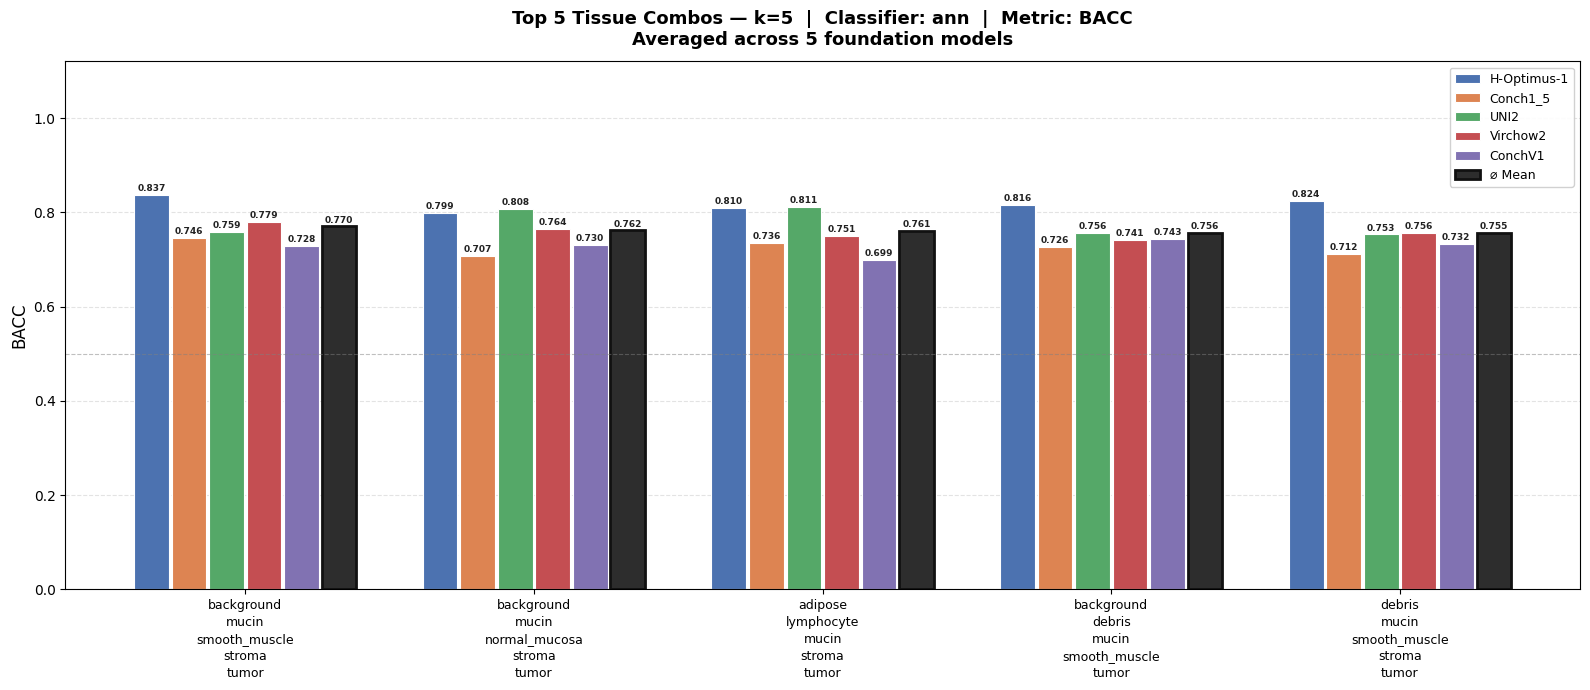

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ────────────────────────────────────────────────────────────
BASE_UPDATED = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\TCGA_Results_Updated\Tissue_Type_Clustering"

MODEL_NAMES = [
    "H-Optimus-1",
    "Conch1_5",
    "UNI2",
    "Virchow2",
    "ConchV1"
]

SUBFOLDER = r"1-MSIH\Output"

# Classifier head to filter on — change to "lin", "ann", or "knn"
CLASSIFIER = "ann"

# Metric to rank combos by
RANK_METRIC = "bacc"

# ── Load & filter data for a given k ─────────────────────────────────────────
def load_k(k_val):
    """
    Load tissue_combo_summary_k{k_val}.xlsx for all models.
    Filter rows where the 'model' column starts with CLASSIFIER (case-insensitive).
    Returns a combined dataframe with a model_name column.
    """
    frames = []
    fname = f"tissue_combo_summary_k{k_val}.xlsx"
    for model in MODEL_NAMES:
        path = os.path.join(BASE_UPDATED, model, SUBFOLDER, fname)
        if not os.path.exists(path):
            print(f"[WARN] Not found: {path}")
            continue
        df = pd.read_excel(path)
        if df.empty:
            print(f"[WARN] Empty: {path}")
            continue
        # filter to the chosen classifier head
        df["model"] = df["model"].astype(str)
        df_clf = df[df["model"].str.lower().str.startswith(CLASSIFIER.lower())].copy()
        if df_clf.empty:
            print(f"[WARN] No '{CLASSIFIER}' rows in {path}")
            continue
        df_clf.insert(0, "model_name", model)
        frames.append(df_clf)
        print(f"[OK] {model} k={k_val}: {len(df_clf)} '{CLASSIFIER}' rows")
    return pd.concat(frames, ignore_index=True) if frames else None

# ── Find top-5 combos by averaged metric across all foundation models ─────────
def top5_combos(df, metric=RANK_METRIC):
    """
    Average the metric across all foundation models for each combo.
    Returns a dataframe of top-5 combos with per-model values + mean.
    """
    # pivot: rows = combo, columns = model_name, values = metric
    pivot = (
        df.groupby(["combo", "model_name"])[metric]
        .mean()                        # in case same combo appears twice per model
        .unstack(fill_value=np.nan)
    )
    pivot["mean"] = pivot.mean(axis=1)
    top5 = pivot.nlargest(5, "mean").reset_index()
    return top5

# ── Plot ──────────────────────────────────────────────────────────────────────
def plot_top5(top5, k_val, metric=RANK_METRIC):
    n_combos = len(top5)
    n_models  = len(MODEL_NAMES)
    bar_w     = 0.13
    x         = np.arange(n_combos)

    # one colour per foundation model + one for the mean
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#2d2d2d"]
    all_cols = MODEL_NAMES + ["mean"]

    fig, ax = plt.subplots(figsize=(16, 7))

    for ci, col in enumerate(all_cols):
        if col not in top5.columns:
            continue
        offset = (ci - len(all_cols) / 2 + 0.5) * bar_w
        vals   = top5[col].values
        color  = palette[ci]
        lw     = 2.0 if col == "mean" else 0.8
        ec     = "#111111" if col == "mean" else "white"
        lbl    = "⌀ Mean" if col == "mean" else col

        for bi in range(n_combos):
            v = vals[bi]
            if np.isnan(v):
                continue
            ax.bar(x[bi] + offset, v, width=bar_w - 0.01,
                   color=color, edgecolor=ec, linewidth=lw,
                   label=lbl if bi == 0 else "")

            # value above bar
            ax.text(x[bi] + offset, v + 0.004, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=6.5,
                    fontweight="bold", color="#222222")

    # x-axis: combo names split on '+' for readability
    combo_labels = [
        "\n".join([p.strip() for p in c.split("+") if p.strip()])
        for c in top5["combo"]
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(combo_labels, fontsize=9, linespacing=1.4)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_title(
        f"Top 5 Tissue Combos — k={k_val}  |  Classifier: {CLASSIFIER}  |  Metric: {metric.upper()}\n"
        f"Averaged across {len(MODEL_NAMES)} foundation models",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=9,
              loc="upper right", framealpha=0.9)

    fig.tight_layout()
    out_path = os.path.join(os.getcwd(), f"top5_combos_k{k_val}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()

# ── Main ──────────────────────────────────────────────────────────────────────
for k in [3, 5]:
    df = load_k(k)
    if df is None:
        print(f"[WARN] No data for k={k}, skipping chart.")
        continue
    top5 = top5_combos(df, RANK_METRIC)
    print(f"\nTop 5 combos for k={k}:")
    print(top5[["combo", "mean"] + [m for m in MODEL_NAMES if m in top5.columns]].to_string(index=False))
    plot_top5(top5, k)